# Multiscale loss run — diagnostics vs the seed ruler

This notebook evaluates the models trained with the multiscale loss on the 1.0x event. The results are compared with the baseline and the seed ruler using summary metrics, false positive and false negative maps, and a check of the coarse scales.

In [1]:
import sys, os
os.environ.setdefault('OMP_NUM_THREADS', '1')   # local torch crashes if multithreaded
os.environ.setdefault('MKL_NUM_THREADS', '1')

try:
    import pyproj
    _proj_db = pyproj.datadir.get_data_dir()
    os.environ.setdefault('PROJ_DATA', _proj_db)
    os.environ.setdefault('PROJ_LIB',  _proj_db)
except Exception:
    pass

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass   # already set, or parallel work started (re-running this cell in a live kernel)
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Models to compare

In [2]:
CONFIG       = 'configs/config_best_sweep.yaml'   # architecture is auto-detected per checkpoint
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart'

def _pair(name, base):
    '''both checkpoints of one run: <base>.h5 (best val_loss) and <base>_bestCSI.h5'''
    return [
        {'name': f'{name}_bestvalloss', 'checkpoint': os.path.join(REPO_ROOT, 'results', base + '.h5')},
        {'name': f'{name}_bestCSI',     'checkpoint': os.path.join(REPO_ROOT, 'results', base + '_bestCSI.h5')},
    ]

MODELS = (
      _pair('baseline_666',       'best_sweep_new_gt')
    + _pair('multiscale_666',     'best_sweep_multiscale_loss')
    + _pair('multiscale_seed1',   'best_sweep_multiscale_loss_seed1')
    + _pair('multiscale_seed200', 'best_sweep_multiscale_loss_seed200')
    + _pair('multiscale_batch8',  'best_sweep_multiscale_loss_batch8_2')
)

for m in MODELS:
    exists = os.path.exists(m['checkpoint'])
    size = f"{os.path.getsize(m['checkpoint'])/1e6:.1f} MB" if exists else 'MISSING'
    print(f"{m['name']:<28} exists={exists!s:<6} {size:>10}  {m['checkpoint']}")

baseline_666_bestvalloss     exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_new_gt.h5
baseline_666_bestCSI         exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_new_gt_bestCSI.h5
multiscale_666_bestvalloss   exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss.h5
multiscale_666_bestCSI       exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss_bestCSI.h5
multiscale_seed1_bestvalloss exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss_seed1.h5
multiscale_seed1_bestCSI     exists=True       2.5 MB  c

## The ruler (from seed_ruler_table.ipynb)

In [3]:
seed_table = pd.read_csv('results/seed_table.csv')
ruler = seed_table[seed_table.ckpt == 'best_CSI']
RULER_LO, RULER_HI = ruler.CSI_005.min(), ruler.CSI_005.max()
print(f'best_CSI ruler, n={len(ruler)} seeds:')
print(f"  CSI@0.05: mean={ruler.CSI_005.mean():.4f} +- {ruler.CSI_005.std(ddof=1):.4f}   band [{RULER_LO:.4f}, {RULER_HI:.4f}]")
print(f"  RMSE_WD : mean={ruler.RMSE_WD.mean():.4f} +- {ruler.RMSE_WD.std(ddof=1):.4f}")
print(f"  CSI@0.30: mean={ruler.CSI_03.mean():.4f} +- {ruler.CSI_03.std(ddof=1):.4f}")

best_CSI ruler, n=5 seeds:
  CSI@0.05: mean=0.7609 +- 0.0419   band [0.7116, 0.8111]
  RMSE_WD : mean=0.1690 +- 0.0217
  CSI@0.30: mean=0.7717 +- 0.0482


## Load shared config and dataset
Same test rollout is reused for every checkpoint, so the comparison is apples-to-apples.

In [4]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 119])


## Load each checkpoint and run inference
Architecture (hid_features, K) is auto-detected from each checkpoint's state_dict.

In [5]:
def load_model_from_checkpoint(checkpoint_path):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features,
        num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'],
        device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': config['lr_info'],
        'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(
        checkpoint_path, map_location=device, **plmodule_kwargs
    )
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list, ckpt.get('epoch', -1)


results = {}
for m in MODELS:
    name, ckpt_path = m['name'], m['checkpoint']
    if not os.path.exists(ckpt_path):
        print(f'[skip] {name}: checkpoint not found')
        continue
    print(f'Loading {name} ...')
    model, hid, K_list, epoch = load_model_from_checkpoint(ckpt_path)

    plot_rollout = PlotRollout(
        model, test_dataset[0], scalers=scalers,
        warmup_steps=0, **temporal_test_dataset_parameters
    )

    rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
    loss_mean = rollout_loss.mean(0)
    rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()

    csi_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]
    csi_curve = [plot_rollout._get_CSI(water_threshold=t).nanmean().item() for t in csi_thresholds]

    csi_time_005 = plot_rollout._get_CSI(water_threshold=0.05).detach().cpu().numpy()
    csi_time_03  = plot_rollout._get_CSI(water_threshold=0.30).detach().cpu().numpy()
    if csi_time_005.ndim > 1:
        csi_time_005 = np.nanmean(csi_time_005, axis=0)
        csi_time_03  = np.nanmean(csi_time_03, axis=0)

    results[name] = {
        'hid_features': hid,
        'K': K_list,
        'epoch': epoch,
        'rmse_wd': rmse_wd,
        'csi_005': csi_curve[csi_thresholds.index(0.05)],
        'csi_03':  csi_curve[csi_thresholds.index(0.30)],
        'csi_thresholds': csi_thresholds,
        'csi_curve': csi_curve,
        'csi_time_005': csi_time_005,
        'csi_time_03': csi_time_03,
        'plot_rollout': plot_rollout,
    }
    print(f'  epoch={epoch} hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={results[name]["csi_005"]:.4f}  CSI@0.30={results[name]["csi_03"]:.4f}')

Loading baseline_666_bestvalloss ...
  epoch=922 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1461  CSI@0.05=0.6800  CSI@0.30=0.8336
Loading baseline_666_bestCSI ...
  epoch=632 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1600  CSI@0.05=0.7409  CSI@0.30=0.7940
Loading multiscale_666_bestvalloss ...
  epoch=767 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1512  CSI@0.05=0.7826  CSI@0.30=0.8483
Loading multiscale_666_bestCSI ...
  epoch=230 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1857  CSI@0.05=0.8150  CSI@0.30=0.8356
Loading multiscale_seed1_bestvalloss ...
  epoch=535 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1671  CSI@0.05=0.6175  CSI@0.30=0.7734
Loading multiscale_seed1_bestCSI ...
  epoch=197 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.2339  CSI@0.05=0.7430  CSI@0.30=0.7311
Loading multiscale_seed200_bestvalloss ...
  epoch=815 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1577  CSI@0.05=0.7753  CSI@0.30=0.8320
Loading multiscale_seed200_bestCSI ...
  epoch=511 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  R

## Summary table — placed on the ruler

In [6]:
header = f"{'Model':<28} {'epoch':>6} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}  vs ruler [{RULER_LO:.3f}, {RULER_HI:.3f}]"
print(header)
print('-' * len(header))
for name, r in results.items():
    c = r['csi_005']
    verdict = 'ABOVE (improvement)' if c > RULER_HI else ('BELOW (regression)' if c < RULER_LO else 'inside (tie)')
    print(f"{name:<28} {r['epoch']:>6} {r['rmse_wd']:>9.4f} {c:>9.4f} {r['csi_03']:>9.4f}  {verdict}")

Model                         epoch   RMSE_WD  CSI@0.05  CSI@0.30  vs ruler [0.712, 0.811]
------------------------------------------------------------------------------------------
baseline_666_bestvalloss        922    0.1461    0.6800    0.8336  BELOW (regression)
baseline_666_bestCSI            632    0.1600    0.7409    0.7940  inside (tie)
multiscale_666_bestvalloss      767    0.1512    0.7826    0.8483  inside (tie)
multiscale_666_bestCSI          230    0.1857    0.8150    0.8356  ABOVE (improvement)
multiscale_seed1_bestvalloss    535    0.1671    0.6175    0.7734  BELOW (regression)
multiscale_seed1_bestCSI        197    0.2339    0.7430    0.7311  inside (tie)
multiscale_seed200_bestvalloss    815    0.1577    0.7753    0.8320  inside (tie)
multiscale_seed200_bestCSI      511    0.1423    0.8365    0.8480  ABOVE (improvement)
multiscale_batch8_bestvalloss    700    0.1646    0.6852    0.7944  BELOW (regression)
multiscale_batch8_bestCSI       313    0.2018    0.7490    0.77

## Plateau evidence — where to cut the epoch budget for the K=8 run

In [7]:
import glob

ckpt_files = sorted(glob.glob('results/best_sweep_multiscale_loss*.h5'))
epochs = {}
for f in ckpt_files:
    ck = torch.load(f, map_location='cpu', weights_only=False)
    epochs[os.path.basename(f)] = int(ck.get('epoch', -1))

print(f"{'checkpoint':<52} best epoch")
for name, e in epochs.items():
    print(f'{name:<52} {e:>6}')

if epochs:
    e_max = max(epochs.values())
    MARGIN = 150   # so the checkpoint callbacks are not racing the wall
    budget = int(np.ceil((e_max + MARGIN) / 50) * 50)
    print(f'\nmax best epoch = {e_max}')
    print(f'suggested K=8 budget: max_epochs = T_max = {budget}')
    print('(patience 300 stays as a second safety net; with <3 seeds present this is provisional)')

checkpoint                                           best epoch
best_sweep_multiscale_loss.h5                           767
best_sweep_multiscale_loss_K8.h5                        516
best_sweep_multiscale_loss_K8_bestCSI.h5                216
best_sweep_multiscale_loss_batch8_2.h5                  700
best_sweep_multiscale_loss_batch8_2_bestCSI.h5          313
best_sweep_multiscale_loss_batchsize=8.h5               481
best_sweep_multiscale_loss_batchsize=8_bestCSI.h5         0
best_sweep_multiscale_loss_bestCSI.h5                   230
best_sweep_multiscale_loss_seed1.h5                     535
best_sweep_multiscale_loss_seed1_bestCSI.h5             197
best_sweep_multiscale_loss_seed200.h5                   815
best_sweep_multiscale_loss_seed200_bestCSI.h5           511

max best epoch = 815
suggested K=8 budget: max_epochs = T_max = 1000
(patience 300 stays as a second safety net; with <3 seeds present this is provisional)


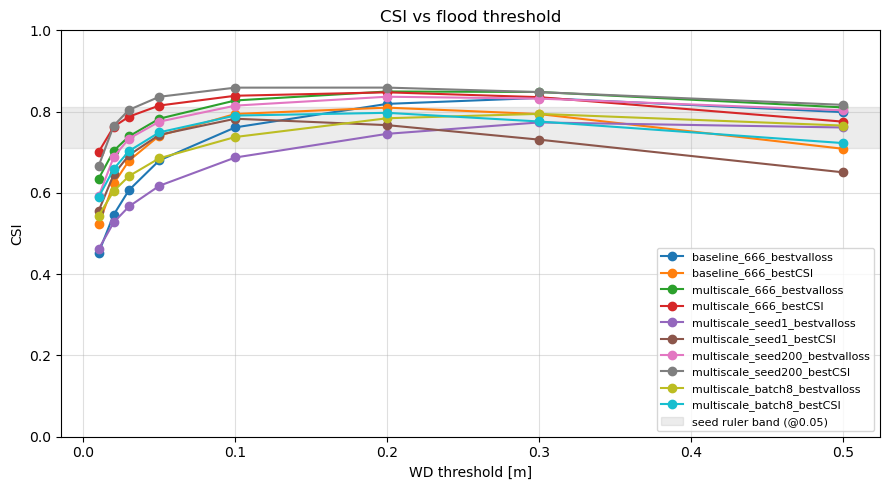

In [8]:
# CSI vs threshold — all models, with the ruler band at 0.05 m
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    ax.plot(r['csi_thresholds'], r['csi_curve'], 'o-', label=name)
ax.axhspan(RULER_LO, RULER_HI, xmin=0, xmax=1, color='grey', alpha=0.15, label='seed ruler band (@0.05)')
ax.set_xlabel('WD threshold [m]')
ax.set_ylabel('CSI')
ax.set_title('CSI vs flood threshold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

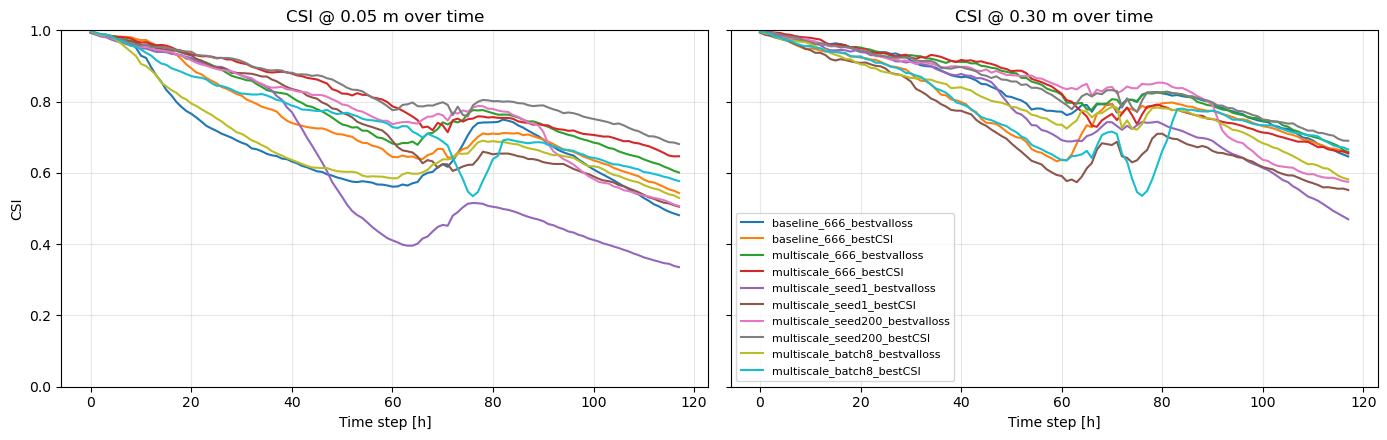

In [9]:
# CSI over time — all models
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for name, r in results.items():
    axes[0].plot(r['csi_time_005'], label=name)
    axes[1].plot(r['csi_time_03'], label=name)
axes[0].set_title('CSI @ 0.05 m over time')
axes[1].set_title('CSI @ 0.30 m over time')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('CSI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## FP/FN decomposition @ 0.05 m

Diagnostic timesteps (of 118): {'rising limb': 71, 'peak': 76, 'recession': 117}


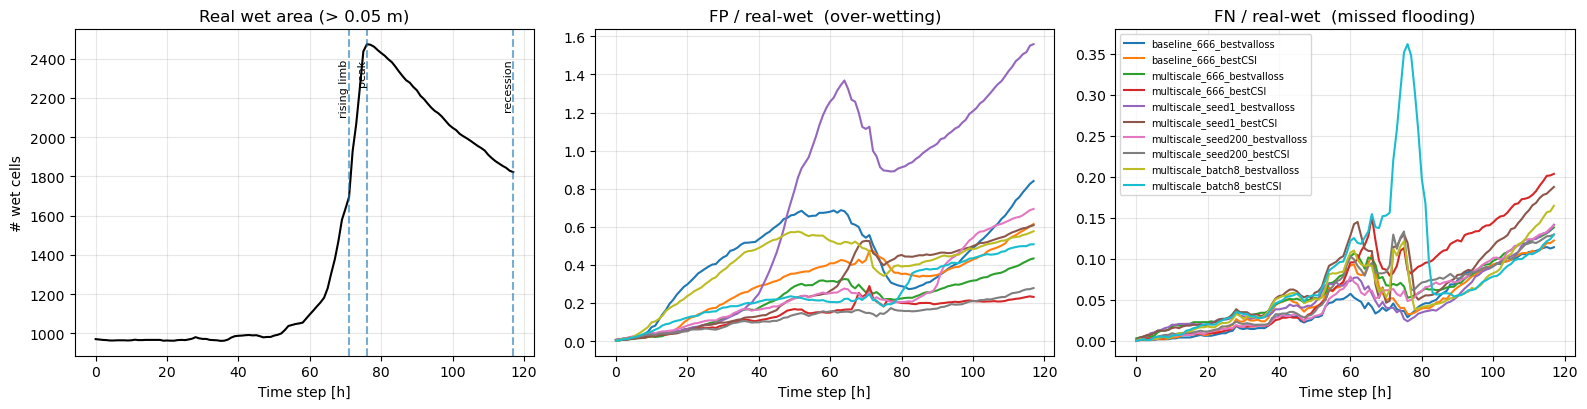

Model                         mean FP/wet  mean FN/wet  dominant error
baseline_666_bestvalloss            0.445        0.044  FP (over-wetting)
baseline_666_bestCSI                0.308        0.051  FP (over-wetting)
multiscale_666_bestvalloss          0.215        0.062  FP (over-wetting)
multiscale_666_bestCSI              0.144        0.075  FP (over-wetting)
multiscale_seed1_bestvalloss        0.726        0.052  FP (over-wetting)
multiscale_seed1_bestCSI            0.287        0.073  FP (over-wetting)
multiscale_seed200_bestvalloss        0.255        0.052  FP (over-wetting)
multiscale_seed200_bestCSI          0.132        0.059  FP (over-wetting)
multiscale_batch8_bestvalloss        0.401        0.059  FP (over-wetting)
multiscale_batch8_bestCSI           0.246        0.080  FP (over-wetting)


In [10]:
from utils.miscellaneous import get_rollout_confusion_matrix

THR = 0.05  # m

real_s0 = next(iter(results.values()))['plot_rollout']._real_rollout_s0  # [nodes, vars, time]
wet_area = (real_s0[:, 0, :] > THR).sum(0).cpu().numpy()

t_peak = int(wet_area.argmax())
base = wet_area[0]
half = base + 0.5 * (wet_area.max() - base)
rise_c = np.where(wet_area[:t_peak] <= half)[0]
t_rise = int(rise_c[-1]) if len(rise_c) else max(t_peak // 2, 1)
rec_c = np.where(wet_area[t_peak:] <= half)[0]
t_rec = int(t_peak + rec_c[0]) if len(rec_c) else int(wet_area.shape[0] - 1)
phases = {'rising limb': t_rise, 'peak': t_peak, 'recession': t_rec}
print(f'Diagnostic timesteps (of {wet_area.shape[0]}):', phases)

conf = {}
for name, r in results.items():
    TP, TN, FP, FN = get_rollout_confusion_matrix(
        r['plot_rollout']._predicted_rollout_s0, r['plot_rollout']._real_rollout_s0,
        water_threshold=THR)
    conf[name] = dict(zip(['TP', 'TN', 'FP', 'FN'],
                          [v.cpu().numpy().astype(float) for v in (TP, TN, FP, FN)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(wet_area, 'k-')
for ph, t in phases.items():
    axes[0].axvline(t, ls='--', alpha=0.6)
    axes[0].annotate(ph, (t, wet_area.max() * 0.97), rotation=90, fontsize=8, ha='right', va='top')
axes[0].set_title(f'Real wet area (> {THR} m)')
axes[0].set_ylabel('# wet cells')

for name, c in conf.items():
    wet = c['TP'] + c['FN']
    axes[1].plot(c['FP'] / wet, label=name)
    axes[2].plot(c['FN'] / wet, label=name)
axes[1].set_title('FP / real-wet  (over-wetting)')
axes[2].set_title('FN / real-wet  (missed flooding)')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.grid(alpha=0.3)
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"{'Model':<28} {'mean FP/wet':>12} {'mean FN/wet':>12}  dominant error")
for name, c in conf.items():
    wet = c['TP'] + c['FN']
    fp, fn = np.nanmean(c['FP'] / wet), np.nanmean(c['FN'] / wet)
    dom = 'FP (over-wetting)' if fp > fn else 'FN (under-prediction)'
    print(f"{name:<28} {fp:>12.3f} {fn:>12.3f}  {dom}")

### Spatial TP / FP / FN maps at rising limb, peak, recession
Red = false alarm (predicted wet, actually dry), orange = miss (predicted dry, actually wet).

In [11]:
# from matplotlib.colors import ListedColormap
# from matplotlib.patches import Patch

# n_s0 = real_s0.shape[0]
# pos_s0 = np.asarray(test_dataset[0].mesh.face_xy)[:n_s0]

# cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])  # TN, TP, FP, FN
# legend_handles = [Patch(color=c, label=l) for c, l in zip(
#     cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

# for name, r in results.items():
#     pred = r['plot_rollout']._predicted_rollout_s0[:, 0, :].cpu().numpy()
#     real = r['plot_rollout']._real_rollout_s0[:, 0, :].cpu().numpy()
#     fig, axes = plt.subplots(1, len(phases), figsize=(16, 5.5))
#     for ax, (ph, t) in zip(axes, phases.items()):
#         p, g = pred[:, t] > THR, real[:, t] > THR
#         cat = np.zeros(n_s0, dtype=int)
#         cat[p & g] = 1
#         cat[p & ~g] = 2
#         cat[~p & g] = 3
#         order = np.argsort(cat, kind='stable')
#         ax.scatter(pos_s0[order, 0], pos_s0[order, 1], c=cat[order], cmap=cat_cmap,
#                    vmin=0, vmax=3, s=2, marker='s', linewidths=0)
#         csi_t = (p & g).sum() / max((p | g).sum(), 1)
#         ax.set_title(f'{ph} (t={t})  CSI={csi_t:.3f}', fontsize=10)
#         ax.set_aspect('equal')
#         ax.set_xticks([]); ax.set_yticks([])
#     fig.suptitle(name, fontsize=11)
#     fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, frameon=False)
#     plt.tight_layout(rect=[0, 0.04, 1, 1])
#     plt.show()

In [12]:
# for name, r in results.items():
#     print(f'--- {name} ---')
#     fig = r['plot_rollout'].explore_rollout(scale=1, time_step=-1)
#     plt.show()

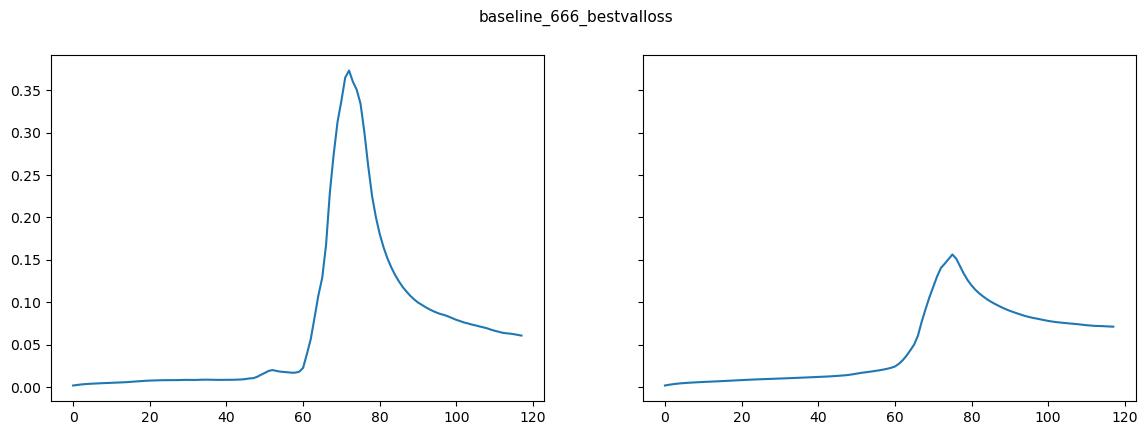

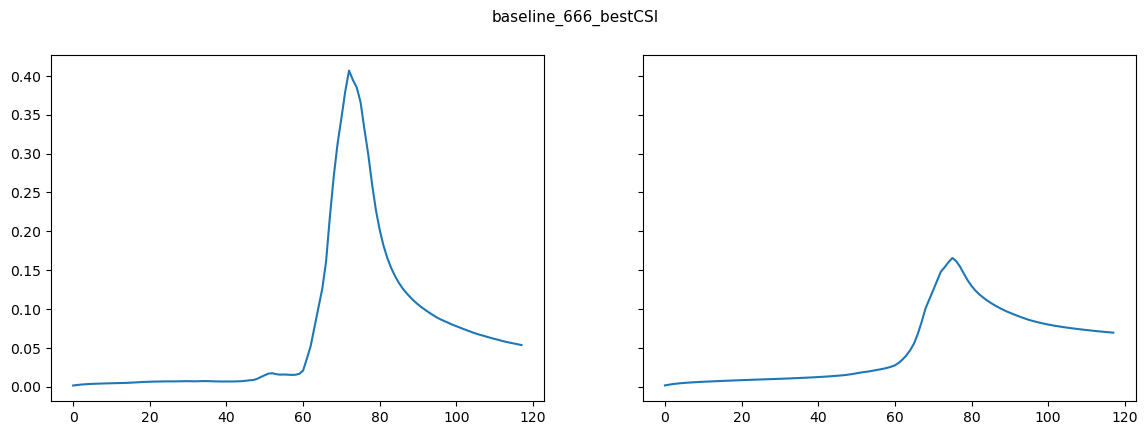

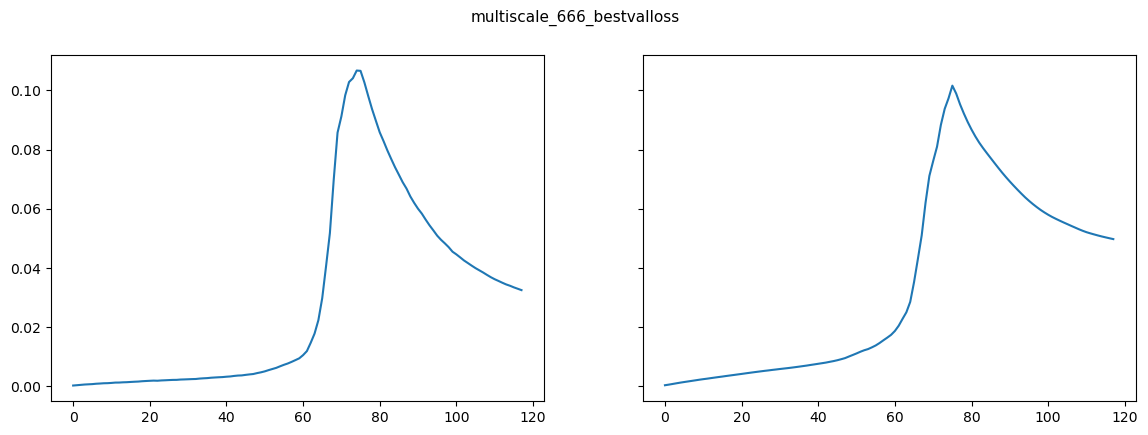

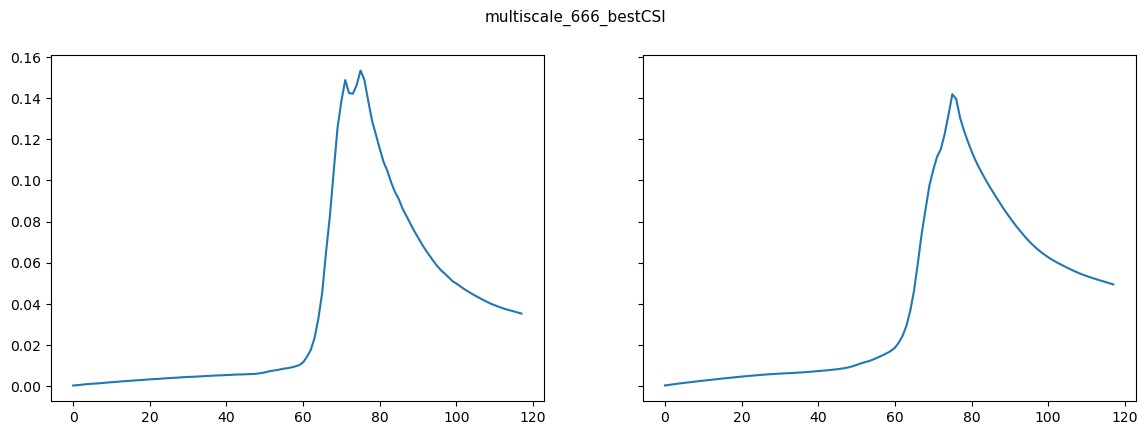

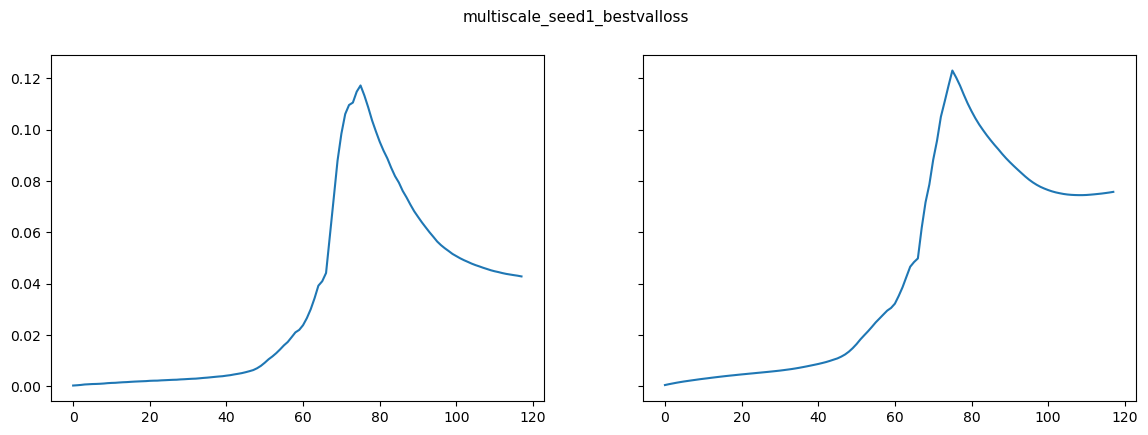

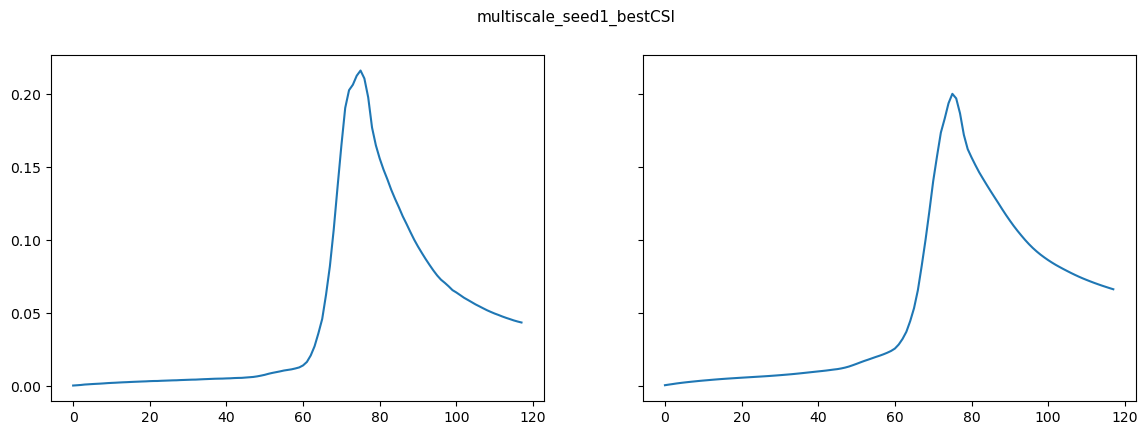

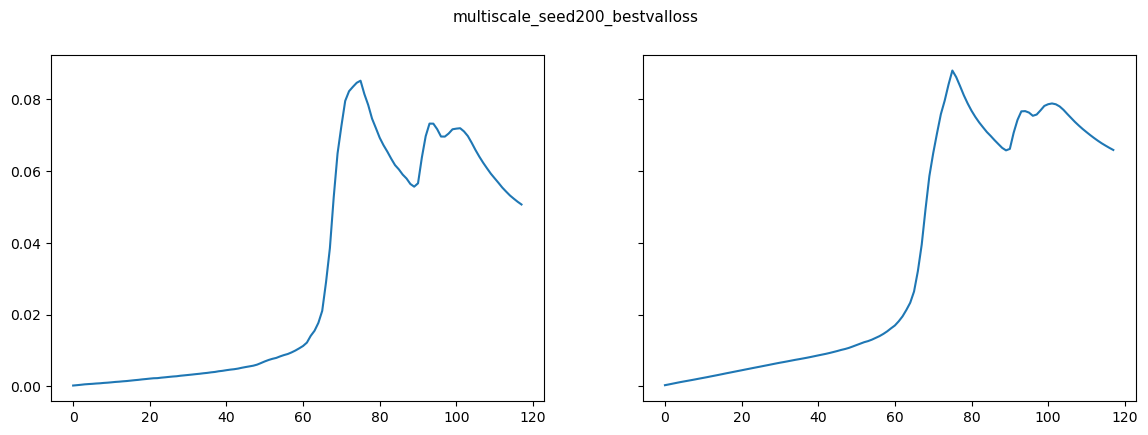

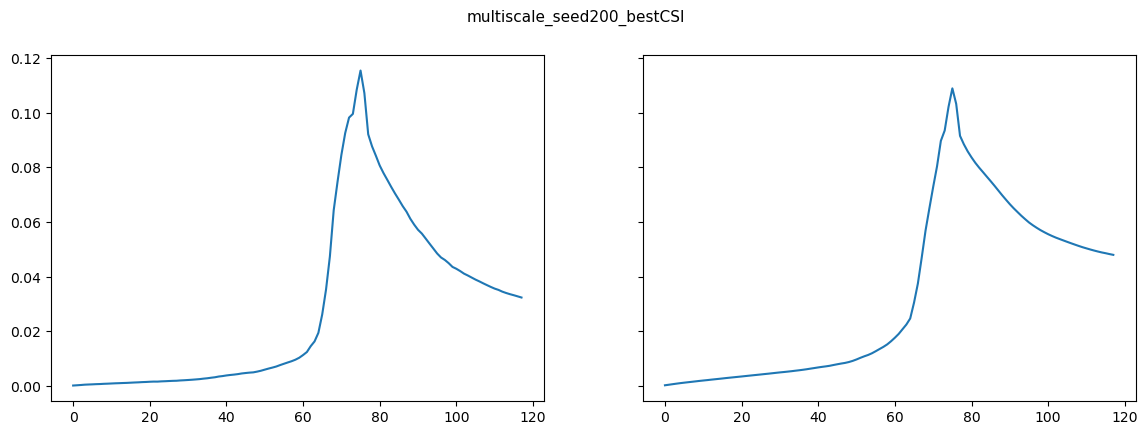

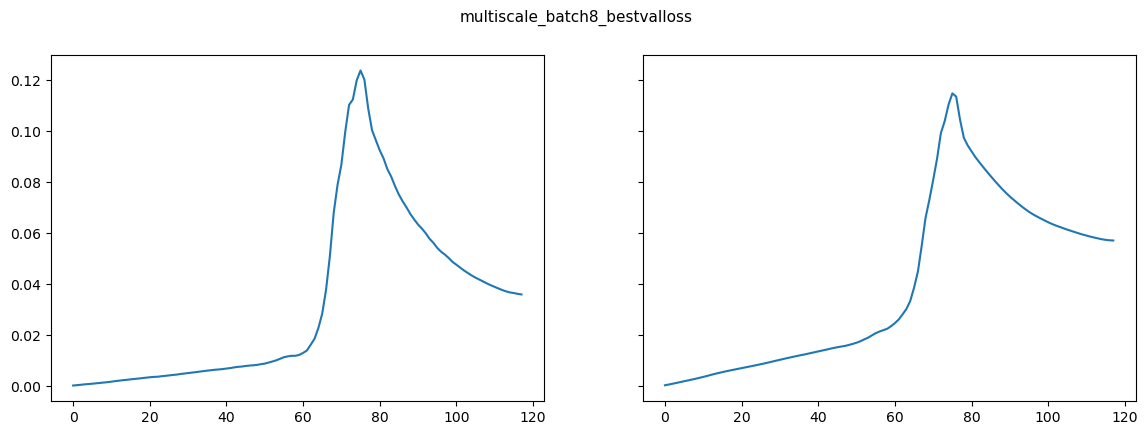

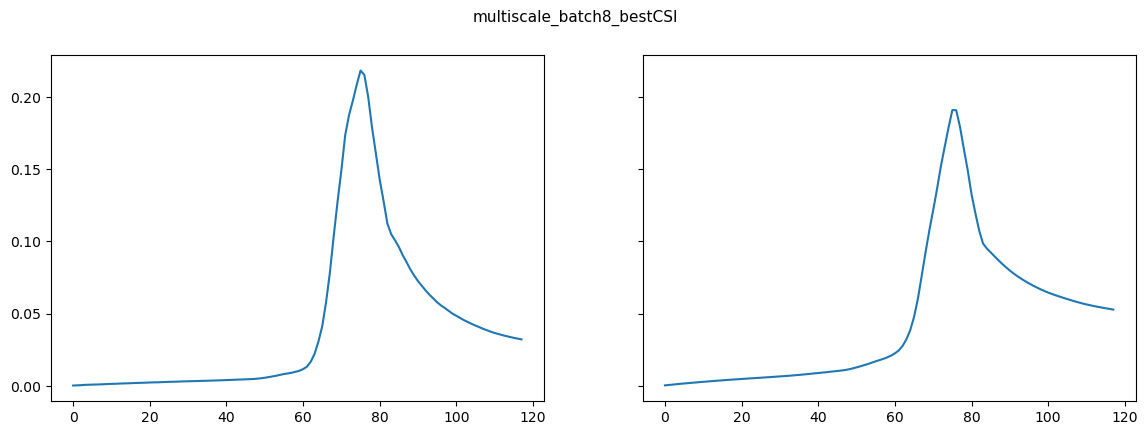

In [13]:
for name, r in results.items():
    figure, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    figure.suptitle(name, fontsize=11)
    axes[0].plot(np.abs(r['plot_rollout'].difference_V.map).mean(0))
    axes[1].plot(np.abs(r['plot_rollout'].difference_WD.map).mean(0))

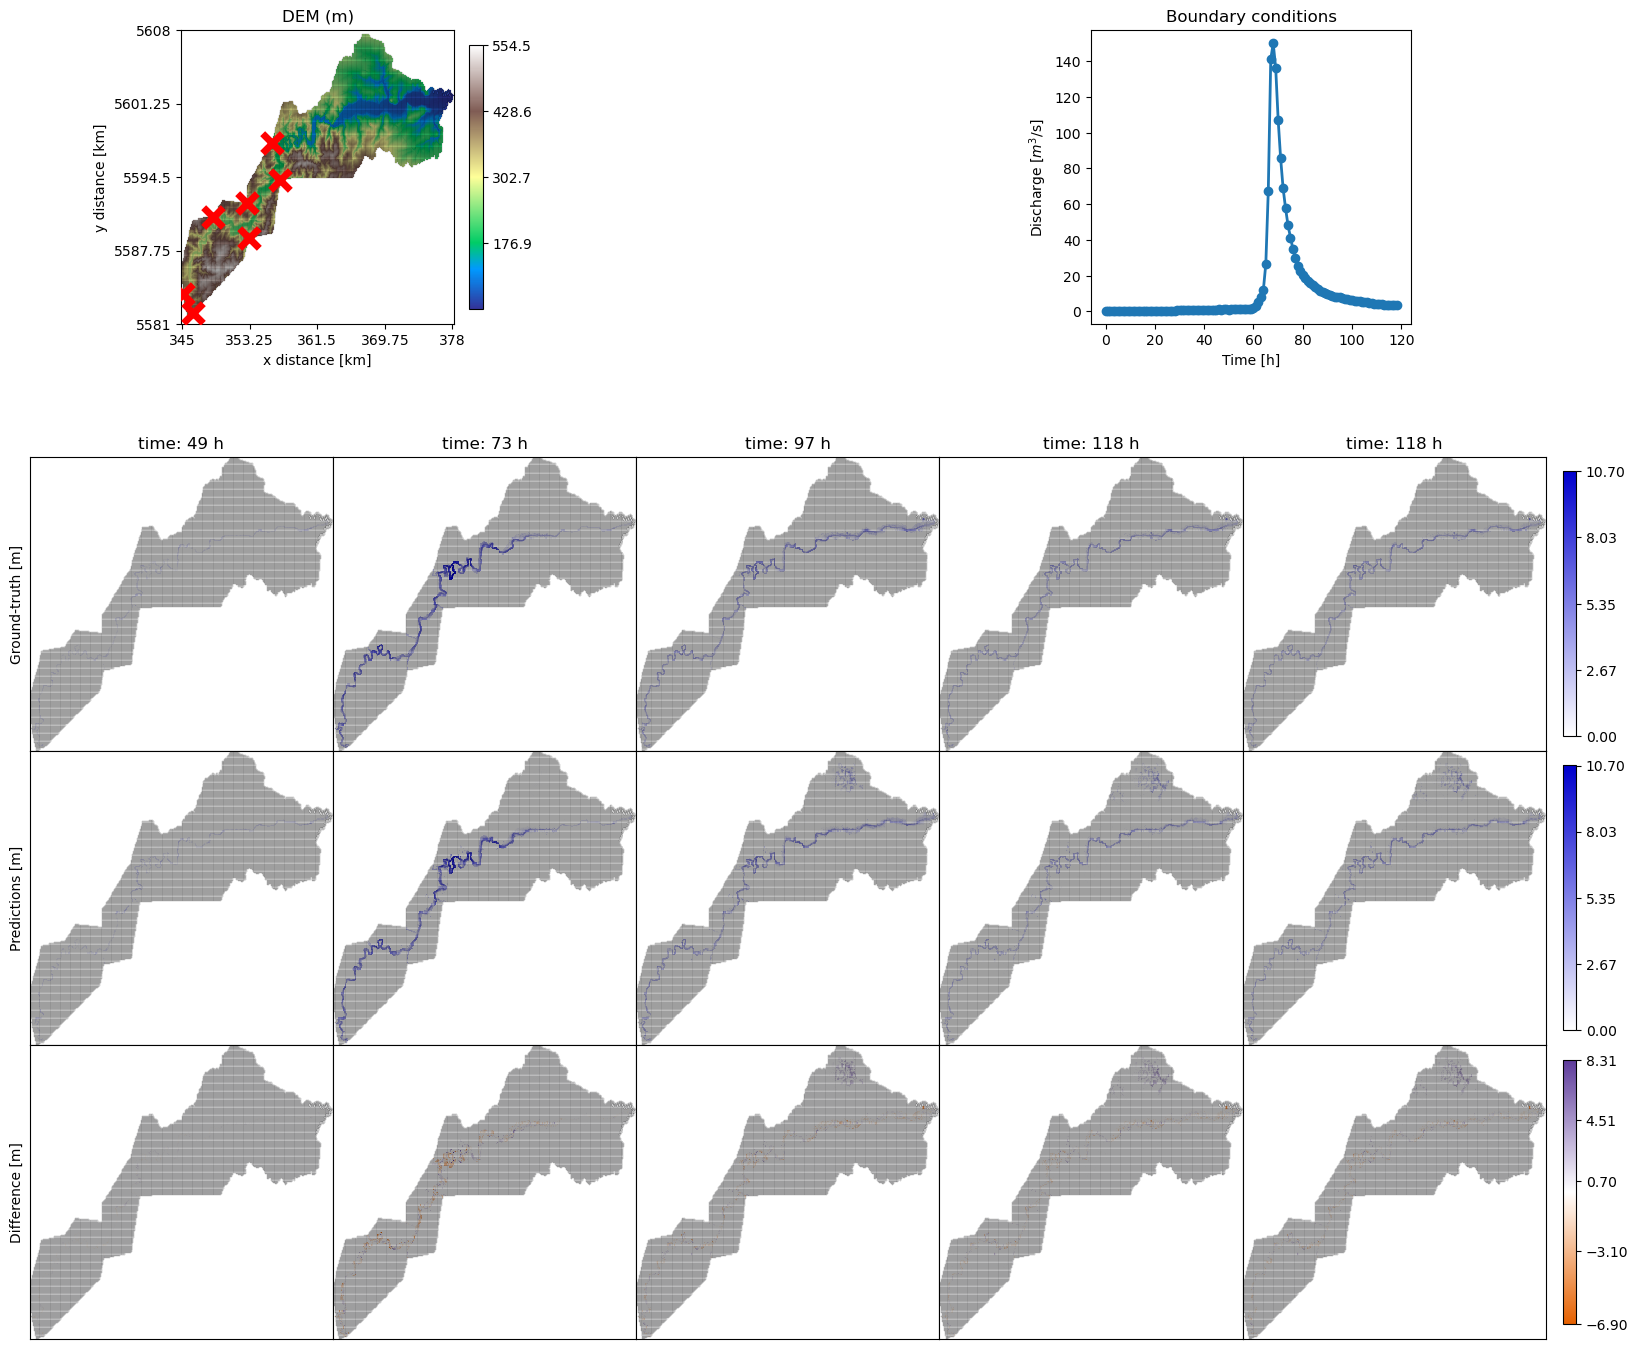

In [14]:
r = results['multiscale_seed200_bestvalloss']
n_steps = r['plot_rollout'].real_rollout.shape[-1]
r['plot_rollout'].compare_h_rollout(plot_times=[48, 72, 96, n_steps - 1], scale=0)
plt.savefig('5.5_foursim_rollout.png', dpi=200, bbox_inches='tight')
plt.show()

## Snapshot the FP/FN/TP maps at peak of 4 models

Loaded foursim_multiscale (epoch 813)
Loaded twentysim_multiscale (epoch 243)


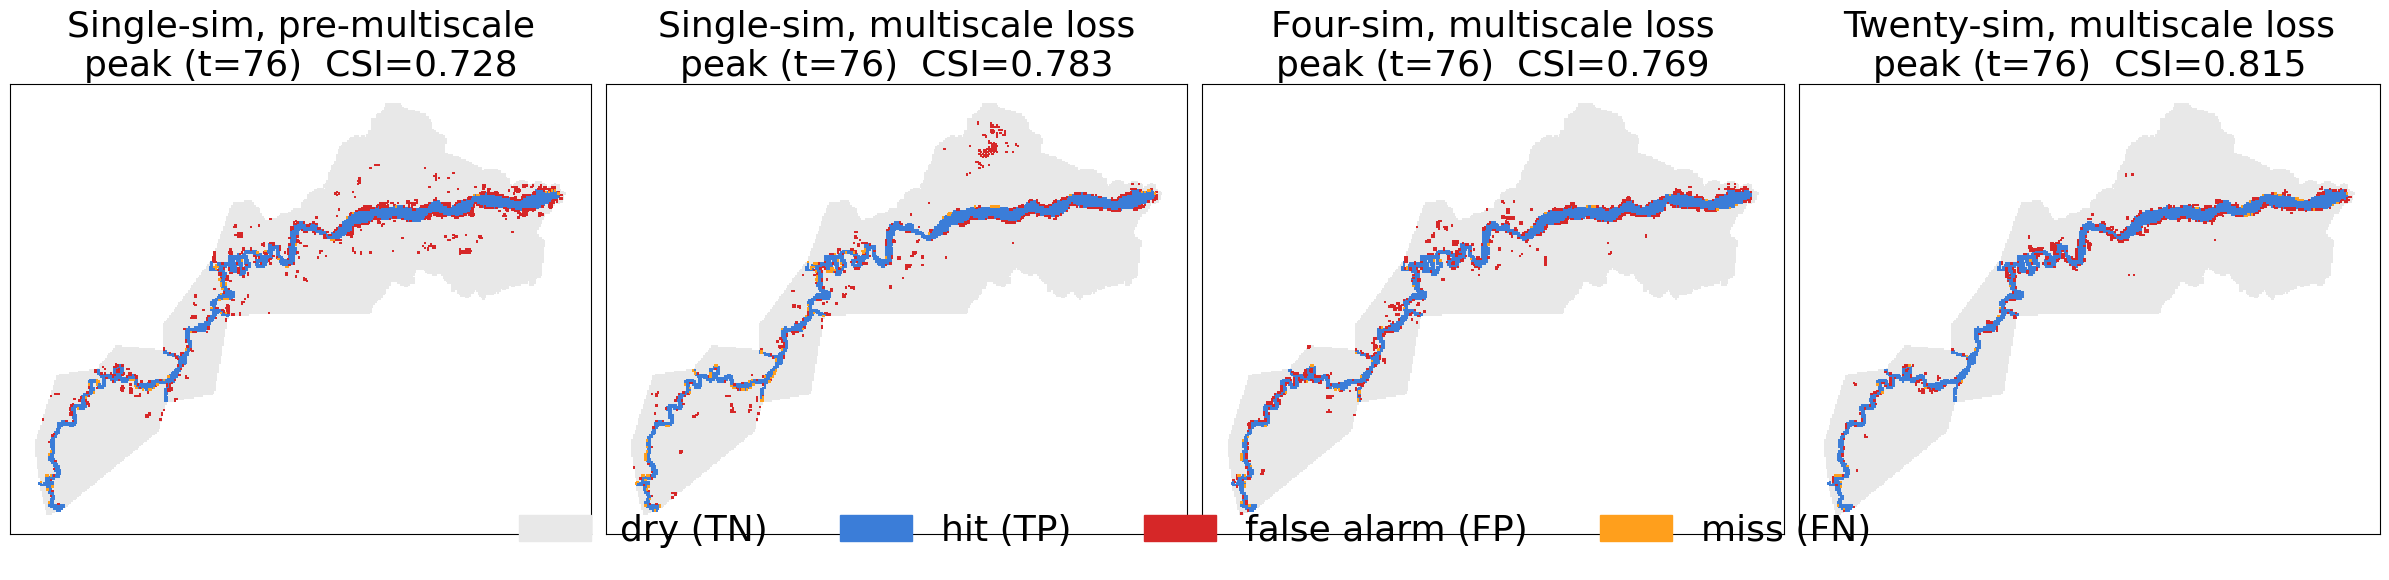

In [18]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

THR_FIG = 0.05  # match the corrected threshold in cell 17

EXTRA_MODELS = {
    'foursim_multiscale':   os.path.join(REPO_ROOT, 'results', 'best_sweep_multisim_multiscale_loss.h5'),
    'twentysim_multiscale': os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment.h5'),
}

extra_plot_rollouts = {}
for name, ckpt_path in EXTRA_MODELS.items():
    if not os.path.exists(ckpt_path):
        print(f'[skip] {name}: checkpoint not found at {ckpt_path}')
        continue
    model_e, hid_e, K_e, epoch_e = load_model_from_checkpoint(ckpt_path)
    extra_plot_rollouts[name] = PlotRollout(
        model_e, test_dataset[0], scalers=scalers,
        warmup_steps=0, **temporal_test_dataset_parameters
    )
    print(f'Loaded {name} (epoch {epoch_e})')

panels = {
    'Single-sim, pre-multiscale':  results['baseline_666_bestvalloss']['plot_rollout'],
    'Single-sim, multiscale loss': results['multiscale_seed200_bestvalloss']['plot_rollout'],
    'Four-sim, multiscale loss':   extra_plot_rollouts.get('foursim_multiscale'),
    'Twenty-sim, multiscale loss': extra_plot_rollouts.get('twentysim_multiscale'),
}
panels = {k: v for k, v in panels.items() if v is not None}

n_s0_fig = panels[next(iter(panels))]._real_rollout_s0.shape[0]
pos_s0_fig = np.asarray(test_dataset[0].mesh.face_xy)[:n_s0_fig]

cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])
legend_handles = [Patch(color=c, label=l) for c, l in zip(
    cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5.5))
if len(panels) == 1:
    axes = [axes]

for ax, (name, pr) in zip(axes, panels.items()):
    real = pr._real_rollout_s0[:, 0, :].cpu().numpy()
    pred = pr._predicted_rollout_s0[:, 0, :].cpu().numpy()
    wet_area_m = (real > THR_FIG).sum(0)
    t_pk_m = int(wet_area_m.argmax())

    p, g = pred[:, t_pk_m] > THR_FIG, real[:, t_pk_m] > THR_FIG
    cat = np.zeros(n_s0_fig, dtype=int)
    cat[p & g] = 1
    cat[p & ~g] = 2
    cat[~p & g] = 3
    order = np.argsort(cat, kind='stable')
    csi_t = (p & g).sum() / max((p | g).sum(), 1)

    ax.scatter(pos_s0_fig[order, 0], pos_s0_fig[order, 1], c=cat[order], cmap=cat_cmap,
               vmin=0, vmax=3, s=3, marker='s', linewidths=0)
    ax.set_title(f'{name}\npeak (t={t_pk_m})  CSI={csi_t:.3f}', fontsize=26)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=26, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('5.7_fp_overwetting_maps_4models.png', dpi=200, bbox_inches='tight')
plt.show()


## Coarse-scale check (multiscale-specific)

In [15]:
from utils.dataset import separate_multiscale_node_features

node_ptr = test_dataset[0].node_ptr
num_scales = len(node_ptr) - 1

print(f"{'Model':<28} " + ' '.join(f'{f"RMSE_WD s{s}":>11}' for s in range(num_scales)))
for name, r in results.items():
    pred_scales = separate_multiscale_node_features(r['plot_rollout'].predicted_rollout, node_ptr)
    real_scales = separate_multiscale_node_features(r['plot_rollout'].real_rollout, node_ptr)
    rmses = []
    for s in range(num_scales):
        diff = (pred_scales[s][:, 0, :] - real_scales[s][:, 0, :])
        rmses.append(torch.sqrt((diff**2).mean()).item())
    print(f"{name:<28} " + ' '.join(f'{v:>11.4f}' for v in rmses))

Model                         RMSE_WD s0  RMSE_WD s1  RMSE_WD s2  RMSE_WD s3
baseline_666_bestvalloss          0.1979      0.3683      0.4818      0.6198
baseline_666_bestCSI              0.2155      0.3766      0.4792      0.6186
multiscale_666_bestvalloss        0.1988      0.1953      0.1880      0.1370
multiscale_666_bestCSI            0.2433      0.2554      0.3200      0.2623
multiscale_seed1_bestvalloss      0.2156      0.2166      0.2034      0.1772
multiscale_seed1_bestCSI          0.3159      0.2985      0.3465      0.2821
multiscale_seed200_bestvalloss      0.2031      0.1997      0.1610      0.2128
multiscale_seed200_bestCSI        0.1935      0.1919      0.1791      0.1614
multiscale_batch8_bestvalloss      0.2103      0.2046      0.1868      0.1449
multiscale_batch8_bestCSI         0.2777      0.2836      0.3101      0.2352
